In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:

from utils.enums import Ticker, TimeFrame
from datetime import datetime
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.pyplot as plt
from utils.enums import Ticker
from feature_extraction.feature_extractor_class import FeatureExtractor
from eda.feature_explorer import FeatureExplorer


/home/raman/IPDA/trading_algo/cmpt-459-project/utils/permutation_test/permute_bars.py:38: UserWarning: feature_selection.opt_thresh not found. Using simplified threshold optimization. For full functionality, ensure the opt_thresh module is available.
  warnings.warn(


In [3]:
# Example 1: Using bias_node_specs (recommended for feature extraction)
bias_node_specs_ts = [
    {
        'module_name': 'ts_feature',
        'timeframes': [TimeFrame.D],
        'params': {
            'wrapped_module': 'rsi',
            'wrapped_params': {'lookback': 2},  # RSI lookback period
            'lookback': 5,  # Time series feature lookback window
            'transformation': 'count_below_mean',  # From utils.functime
            'transformation_name': 'countBelowMean'
        }
    }
]

In [4]:


# Step 1: Extract features using FeatureExtractor
extractor = FeatureExtractor(
    tickers=[
        Ticker.ES,    # E-Mini S&P
        Ticker.NQ,    # E-Mini Nasdaq
        Ticker.YM,    # E-Mini Dow
        Ticker.RTY,   # E-Mini Russell 2000
        # Ticker.HO, 
        # Ticker.GC, 
        # Ticker.SI, 
        # Ticker.CL
        # Add more tickers as needed...
    ],
    start=datetime(2000, 1, 1),
    end=datetime(2024, 12, 31)
)

bias_node_specs = []

windows = range(2,5,1)
avg_windows = range(2,5,1)


for lookback in windows:
    for avg_period in avg_windows:
        bias_node_specs.append({
            'module_name': 'cumulative_rsi',
            'params': {
                'lookback': lookback,
                'avg_period': avg_period
            }
        })


# roc_windows = [2,5,10,20,40,60,80, 100, 120, 140, 160, 180, 200, 252]
# for window in roc_windows:
#     bias_node_specs.append({
#         'module_name': 'roc',
#         'params': {
#             'lookback': window,
#             'normalize_by_ewsd': True,
#         }
#     })
    
#     bias_node_specs.append({
#         'module_name': 'rsi',
#         'params': {
#             'lookback': window,
#         }
#     })



# ewmac = [(16,64), (32,128), (64,256)]
# for spanFast, spanSlow in ewmac:
#     bias_node_specs.append({
#         'module_name': 'ewmac',
#         'params': {
#             'spanFast': spanFast,
#             'spanSlow': spanSlow
#         }
#     })

# Extract features
result = extractor.extract(
    bias_node_specs=bias_node_specs
)

features = result['features']              # Clean features only
normalization = result['normalization']    # ATR/EWSD columns
targets = result['targets']    

# Step 2: Create FeatureExplorer from extracted dataframes
explorer = FeatureExplorer(
    features_df=features,
    targets_df=targets, 
    metadata=result
)





FeatureExtractor Initialized
Tickers: ['ES', 'NQ', 'YM', 'RTY']
Date range: 2000-01-01 to 2024-12-31
Multi-ticker offset: True


Starting Feature Extraction
Bias nodes: 9

Extracting 9 bias node(s) in a single backtest...
✓ Cython node optimizations loaded (5-10x speedup for ATR, EMA, etc.)


Running backtest features:   0%|          | 2/6323 [00:00<16:08,  6.52candles/s]/home/raman/IPDA/trading_algo/cmpt-459-project/feature_extraction/ml_manager.py:130: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  self.matrix = pd.concat([self.matrix, buffer_df])
/home/raman/IPDA/trading_algo/cmpt-459-project/feature_extraction/ml_manager.py:130: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.matrix = pd.concat([self.matrix, buffer_df])
Running backtest features:   0%|          | 0/6324 [00:00<?, ?candles/s]/home/raman/IPDA

✓ Extracted 10 features in single backtest

Combining all modules...
Generating feature metadata by parsing column names
✓ Combined features: 6 feature columns
✓ Normalization columns: 4 (ATR/EWSD)
✓ Date range: 2000-01-03 00:00:00+00:00 to 2024-12-31 00:00:00.003000+00:00
✓ Samples: 20298



In [5]:
# Use custom model and metric
from feature_selection.base_models import QuantileBinningModel
from feature_selection.base_models import DecisionTreeBinningModel
from metrics.performance.sortino import SortinoRatio

model = QuantileBinningModel(n_bins=4, selection_metric='sortino')
metric = SortinoRatio(annualization_factor=252)
decision_tree_model = DecisionTreeBinningModel(n_bins=4, selection_metric='sortino')



In [6]:
features.columns

Index(['cumulative_rsi_signal_D_avgPeriod_2_lookback_2',
       'cumulative_rsi_signal_D_avgPeriod_2_lookback_3',
       'cumulative_rsi_signal_D_avgPeriod_2_lookback_4',
       'cumulative_rsi_signal_D_avgPeriod_3_lookback_3',
       'cumulative_rsi_signal_D_avgPeriod_3_lookback_4',
       'cumulative_rsi_signal_D_avgPeriod_4_lookback_4', 'ticker'],
      dtype='object')


Plotting decile analysis for 6 features
Target: log_return

[1/6] cumulative_rsi_signal_D_avgPeriod_2_lookback_2
  ✓ Complete

[2/6] cumulative_rsi_signal_D_avgPeriod_2_lookback_3
  ✓ Complete

[3/6] cumulative_rsi_signal_D_avgPeriod_2_lookback_4
  ✓ Complete

[4/6] cumulative_rsi_signal_D_avgPeriod_3_lookback_3
  ✓ Complete

[5/6] cumulative_rsi_signal_D_avgPeriod_3_lookback_4
  ✓ Complete

[6/6] cumulative_rsi_signal_D_avgPeriod_4_lookback_4
  ✓ Complete

Completed 6/6 features


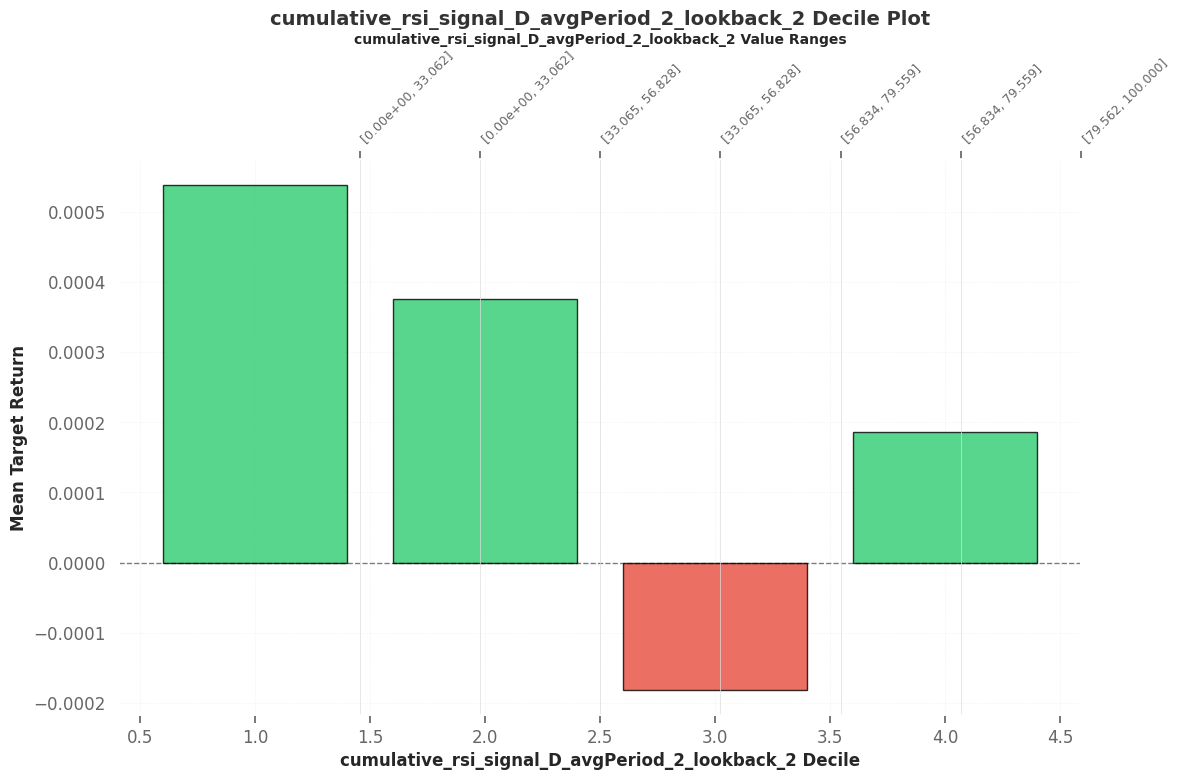

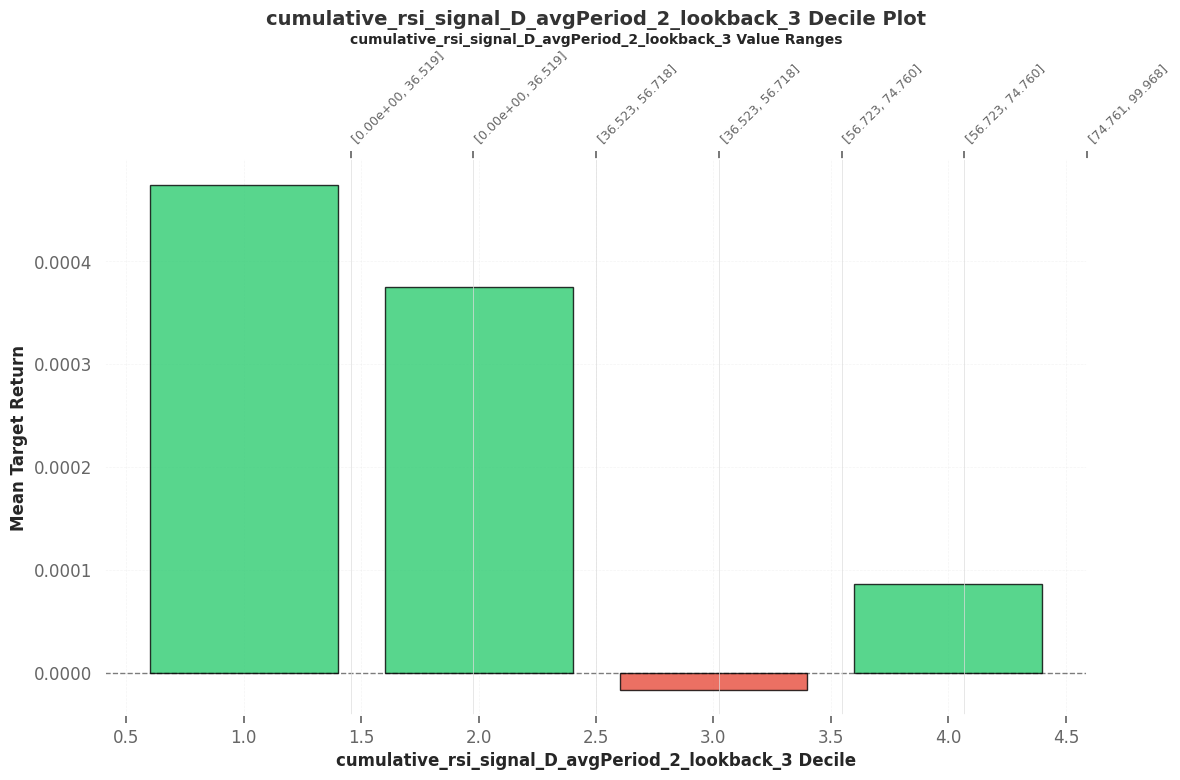

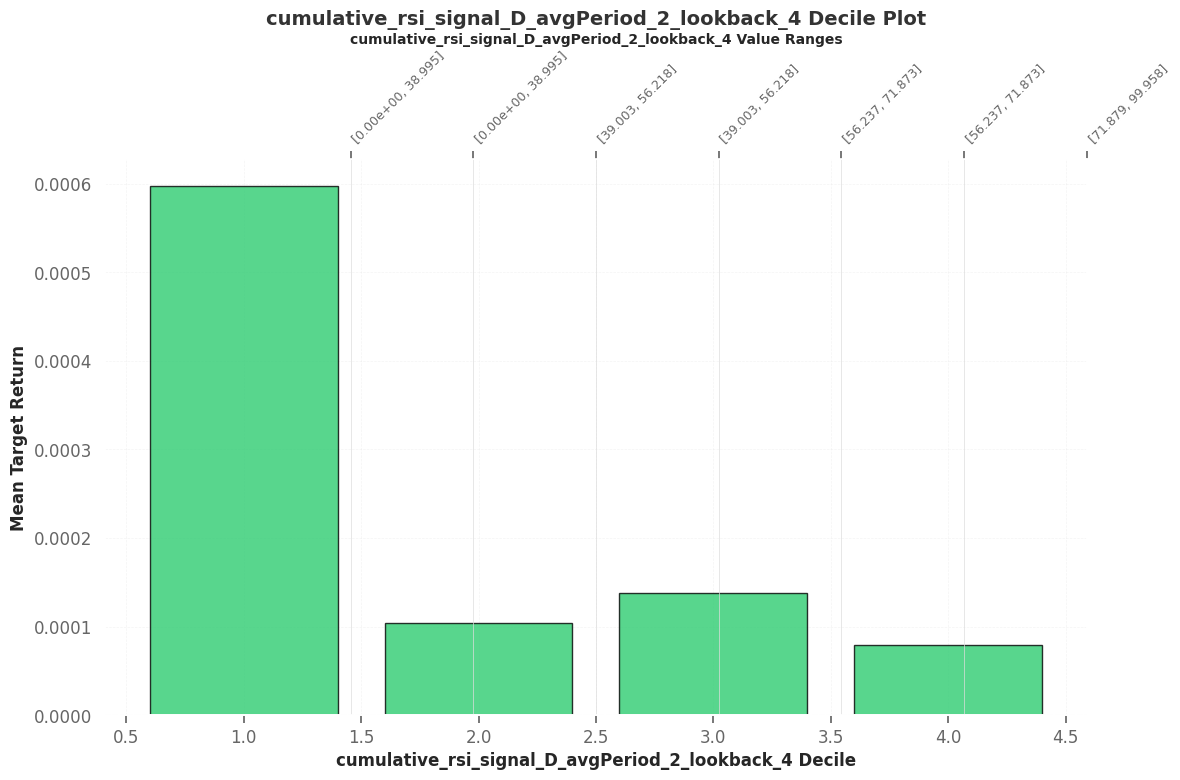

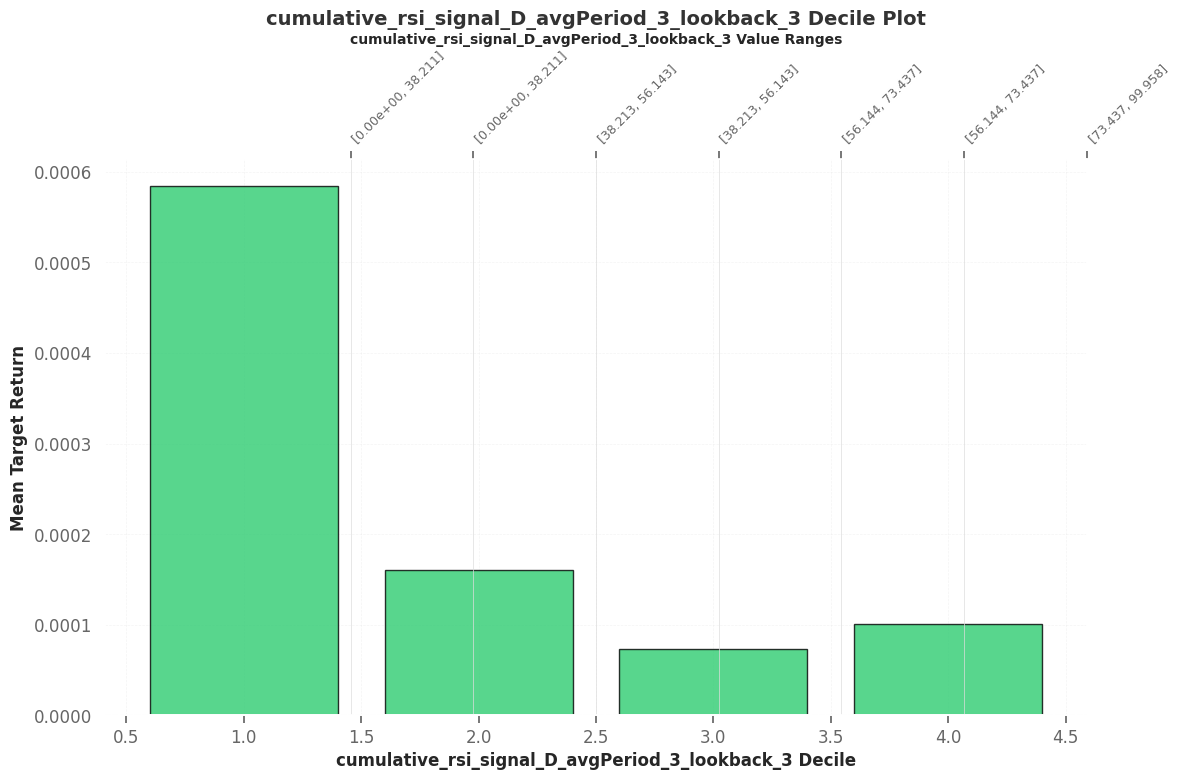

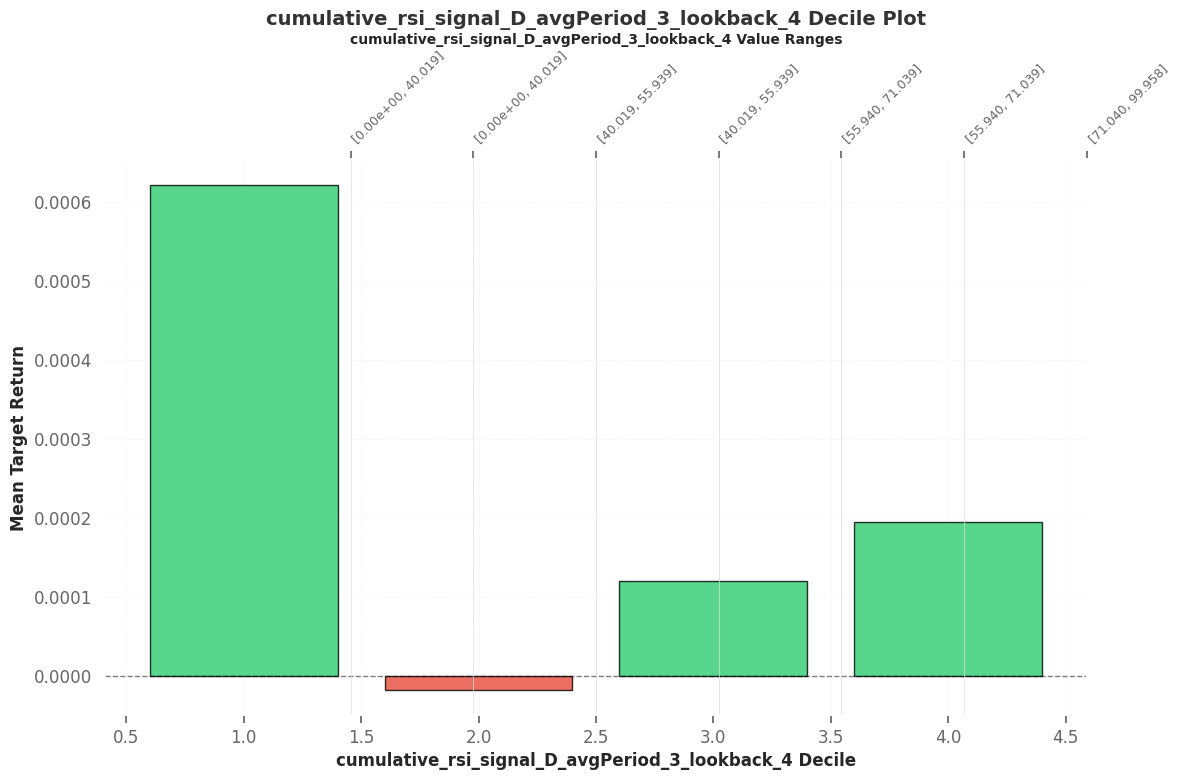

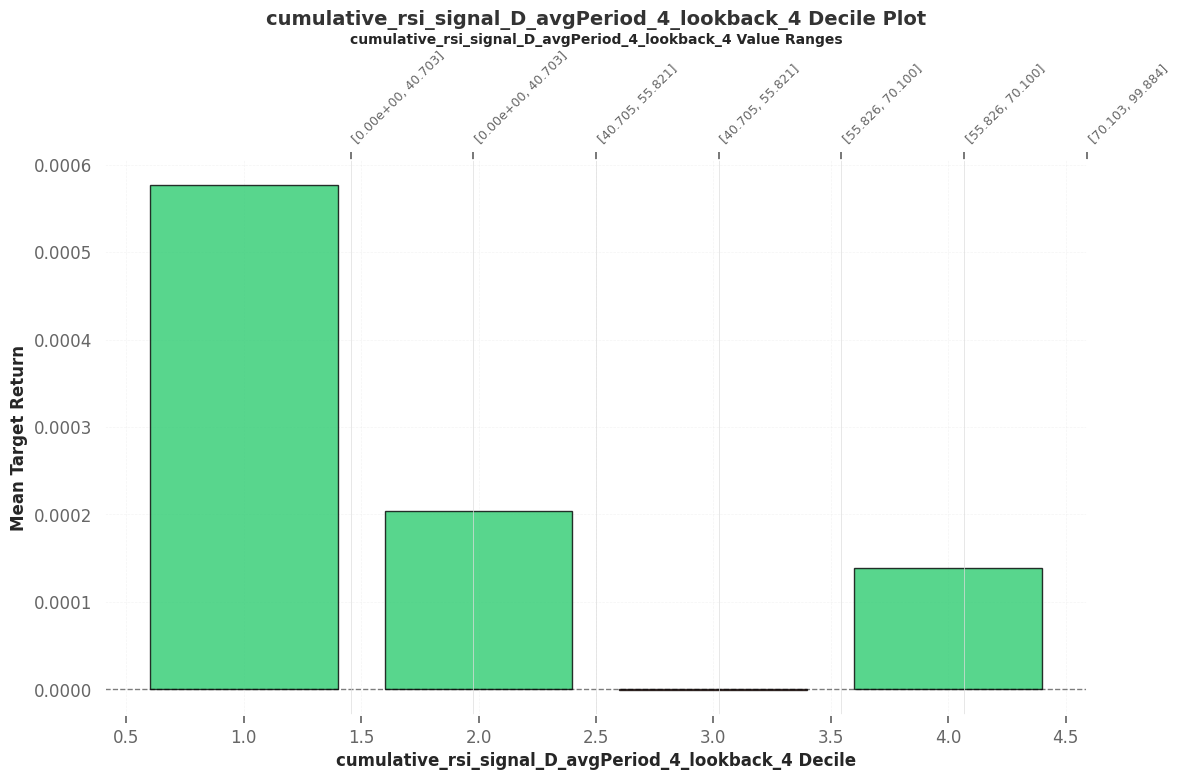

In [7]:

# Step 3: Analyze (same API as before!)
# Plot deciles with log_return
figs = explorer.plot_all_deciles(n_bins=4, target_col='log_return')
plt.show()

# figures = explorer.plot_all_uniform_bins(
#     n_bins=10,
#     target_col='log_return',
# )
# plt.show()

# # # Plot 2-bin for each feature
# for feature_name in explorer.feature_names:
#     explorer.plot_2bin(feature_name, target_col='log_return')
# plt.show()

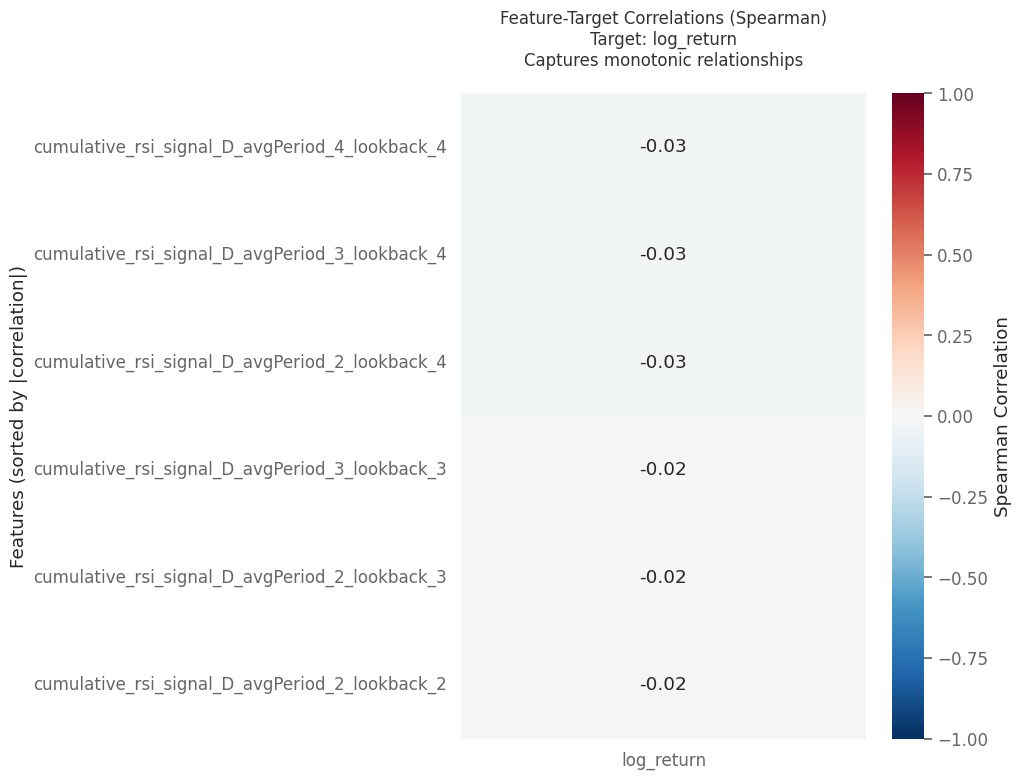

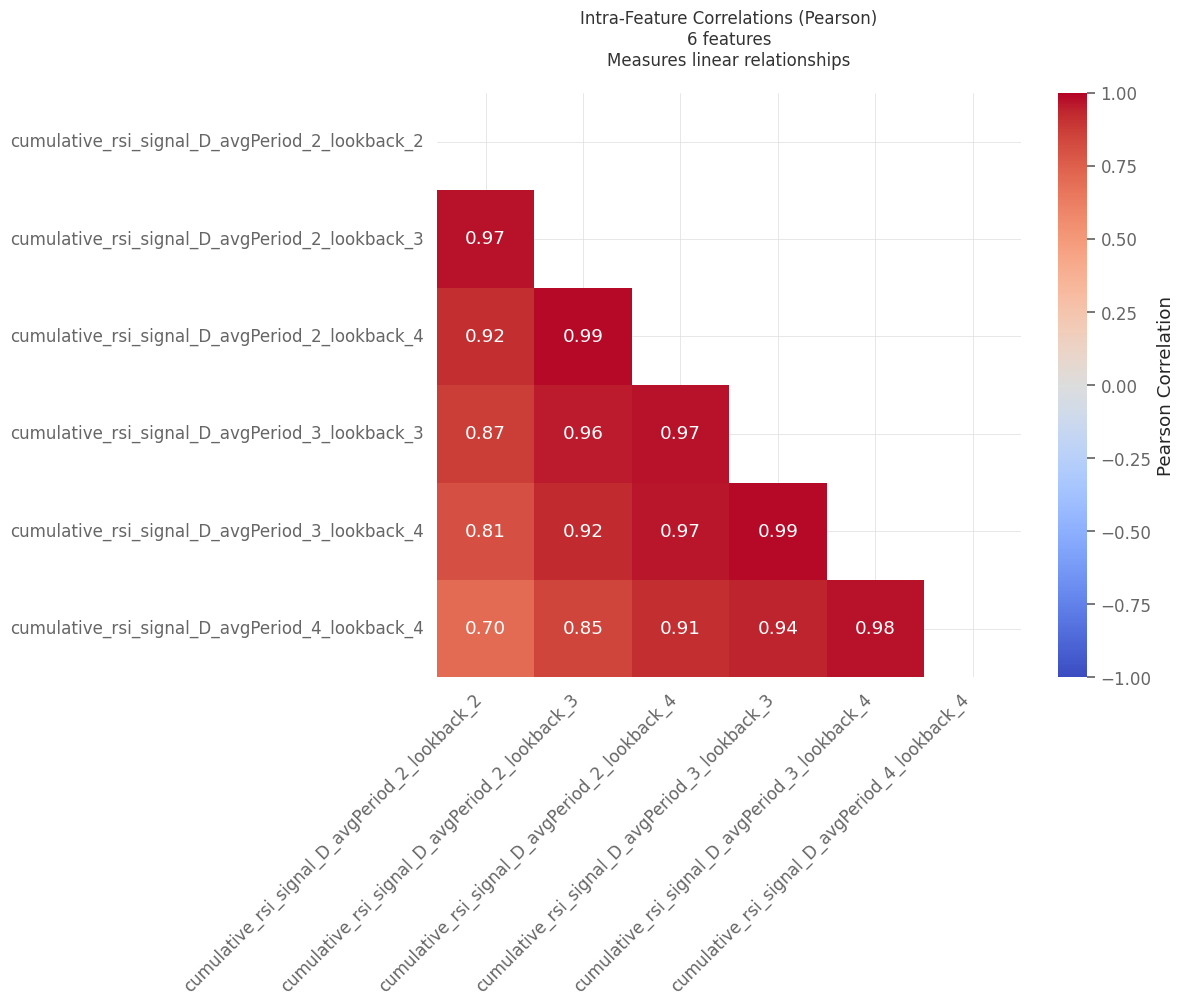

In [8]:

# 1. Feature-Target correlations (Spearman - captures monotonic relationships)
fig1 = explorer.plot_feature_target_correlations(
    target_col='log_return',
    figsize=(10, 8),
    annot=True  # Show correlation values
)
plt.show()

# 2. Intra-Feature correlations (Pearson - linear relationships)
fig2 = explorer.plot_feature_correlations(
    figsize=(12, 10),
    annot=True, 
    mask_diagonal=True  
)
plt.show()


Plotting distributions for 6 features

[1/6] cumulative_rsi_signal_D_avgPeriod_2_lookback_2
  ✓ Complete

[2/6] cumulative_rsi_signal_D_avgPeriod_2_lookback_3
  ✓ Complete

[3/6] cumulative_rsi_signal_D_avgPeriod_2_lookback_4
  ✓ Complete

[4/6] cumulative_rsi_signal_D_avgPeriod_3_lookback_3
  ✓ Complete

[5/6] cumulative_rsi_signal_D_avgPeriod_3_lookback_4
  ✓ Complete

[6/6] cumulative_rsi_signal_D_avgPeriod_4_lookback_4
  ✓ Complete

Completed 6/6 features


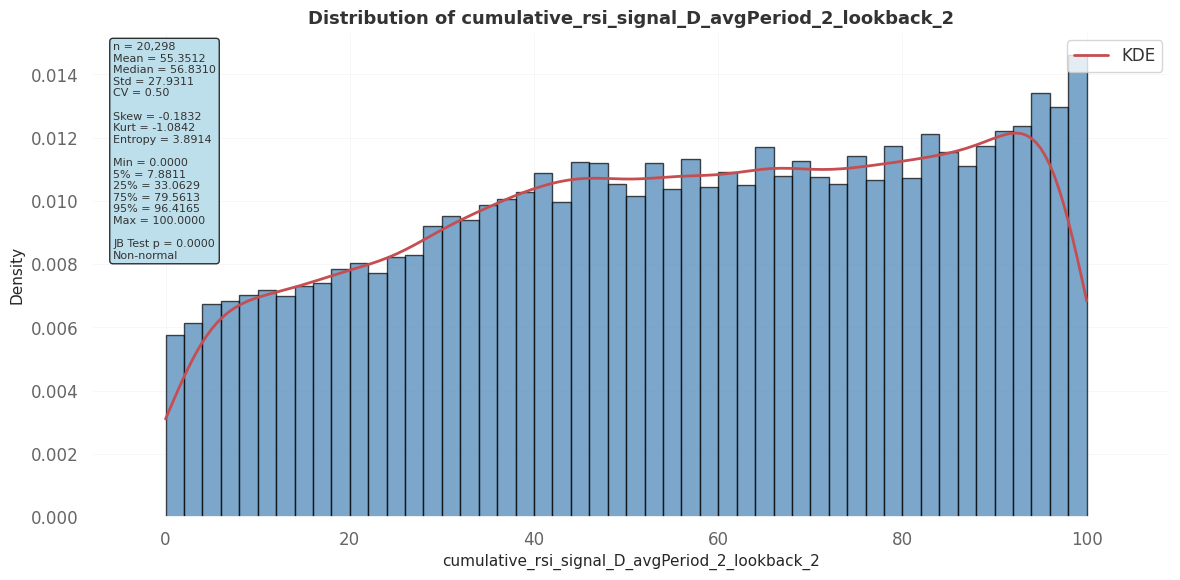

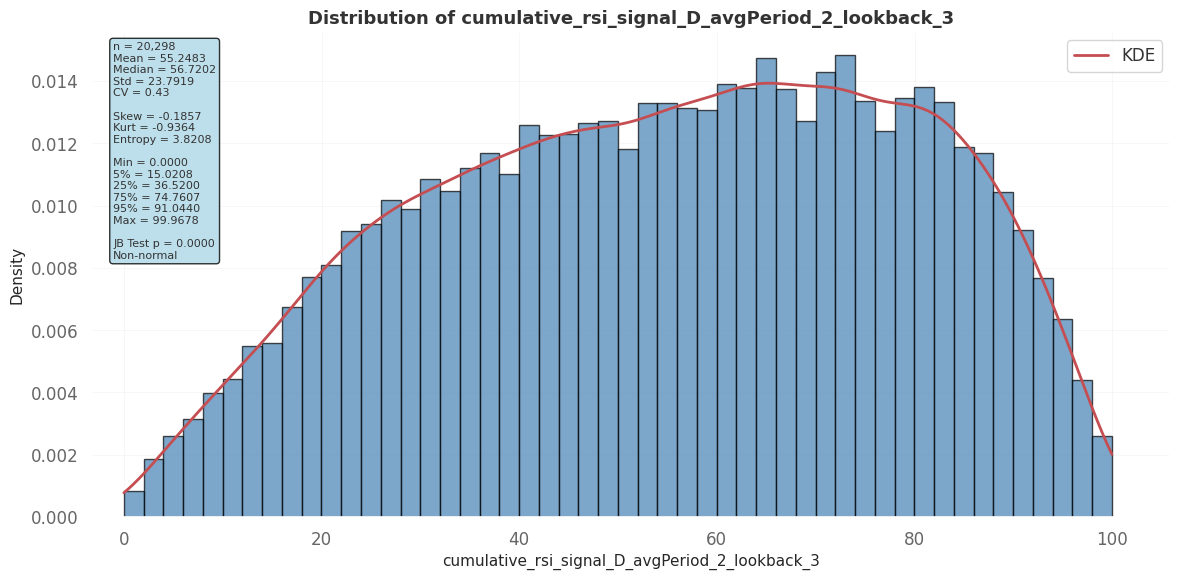

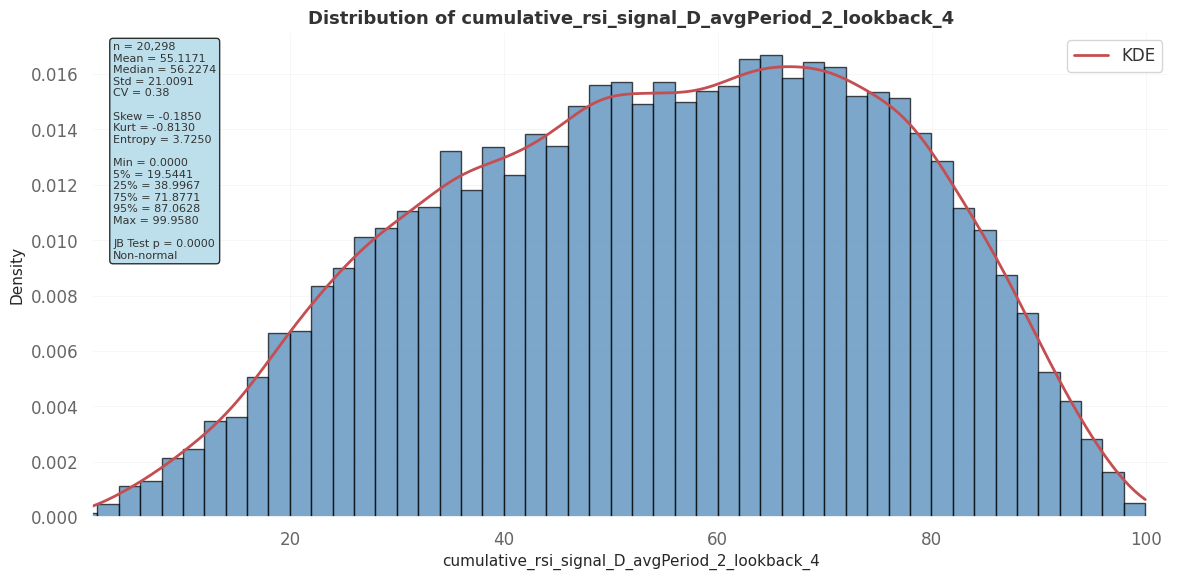

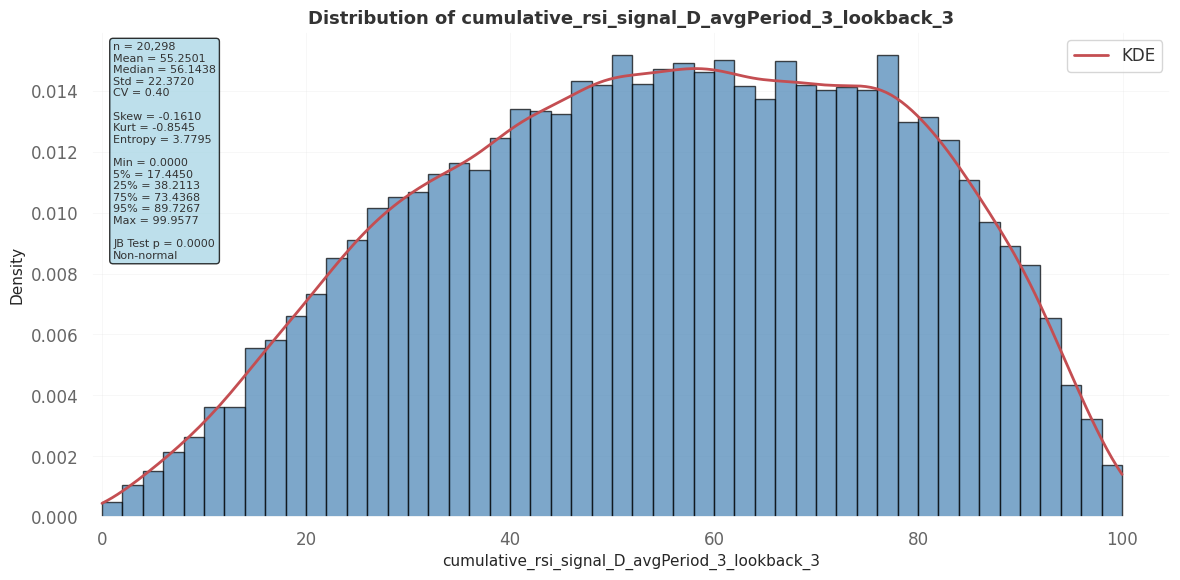

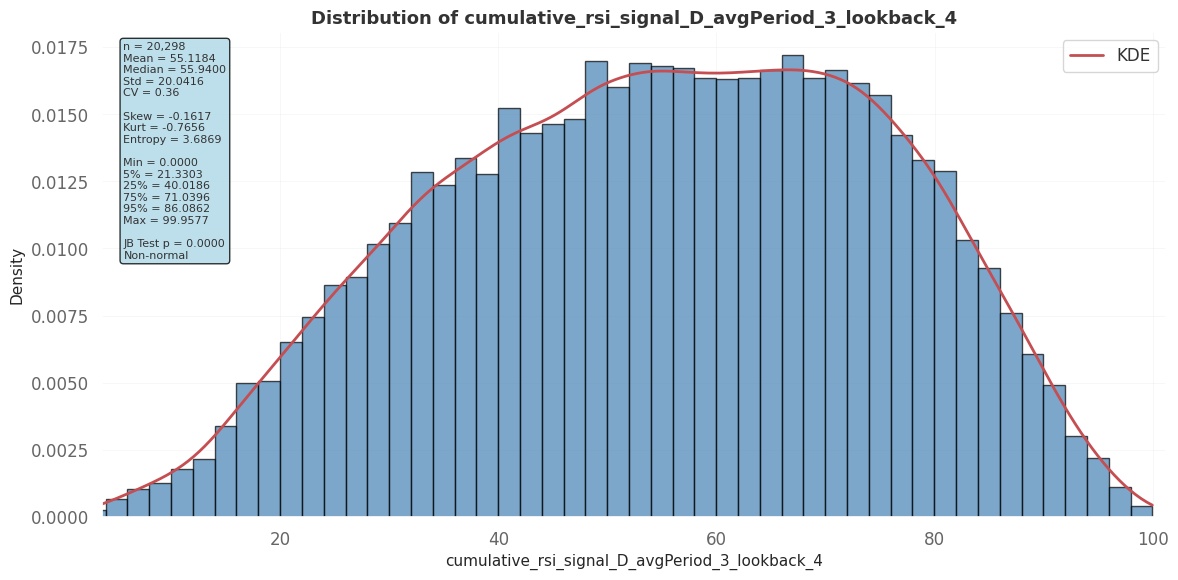

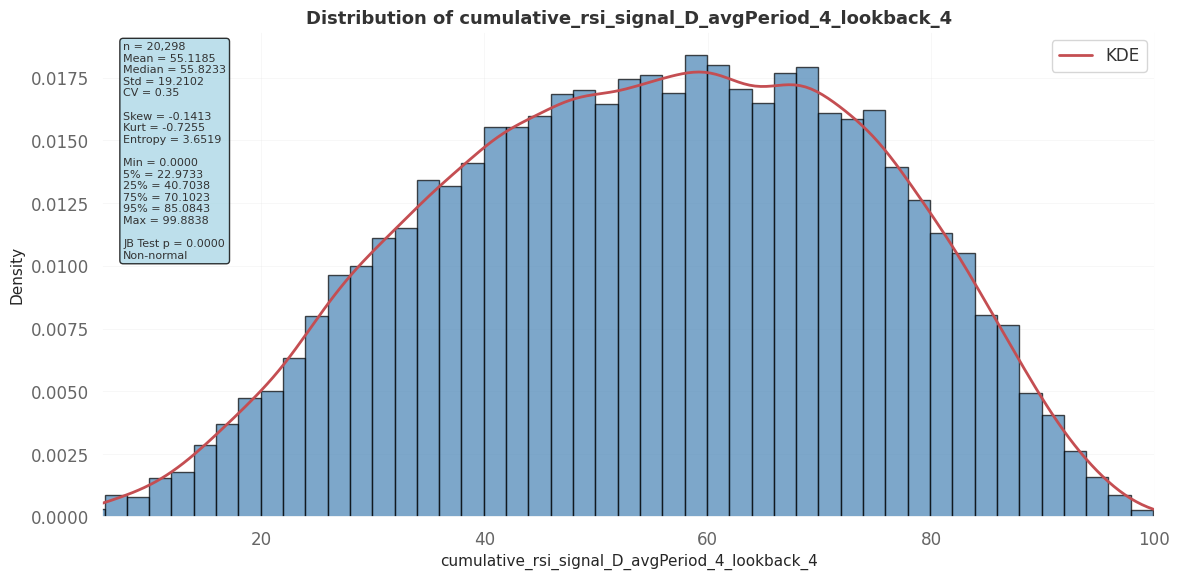


Plotting time series for 6 features

[1/6] cumulative_rsi_signal_D_avgPeriod_2_lookback_2
  ✓ Complete

[2/6] cumulative_rsi_signal_D_avgPeriod_2_lookback_3
  ✓ Complete

[3/6] cumulative_rsi_signal_D_avgPeriod_2_lookback_4
  ✓ Complete

[4/6] cumulative_rsi_signal_D_avgPeriod_3_lookback_3
  ✓ Complete

[5/6] cumulative_rsi_signal_D_avgPeriod_3_lookback_4
  ✓ Complete

[6/6] cumulative_rsi_signal_D_avgPeriod_4_lookback_4
  ✓ Complete

Completed 6/6 features


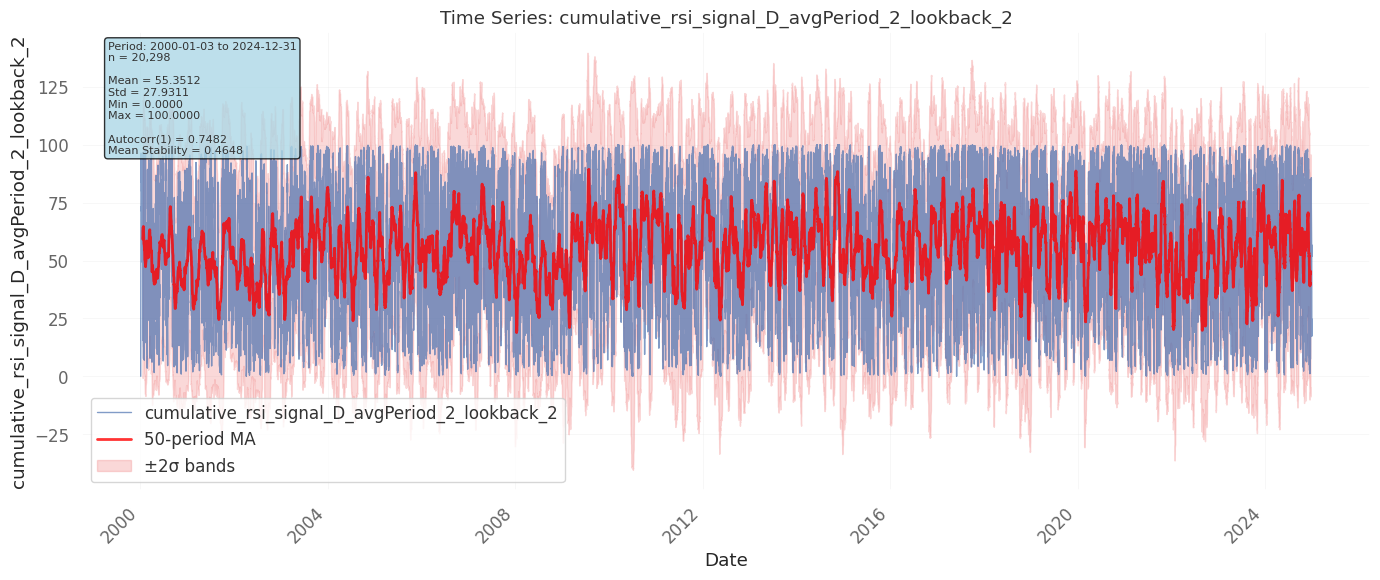

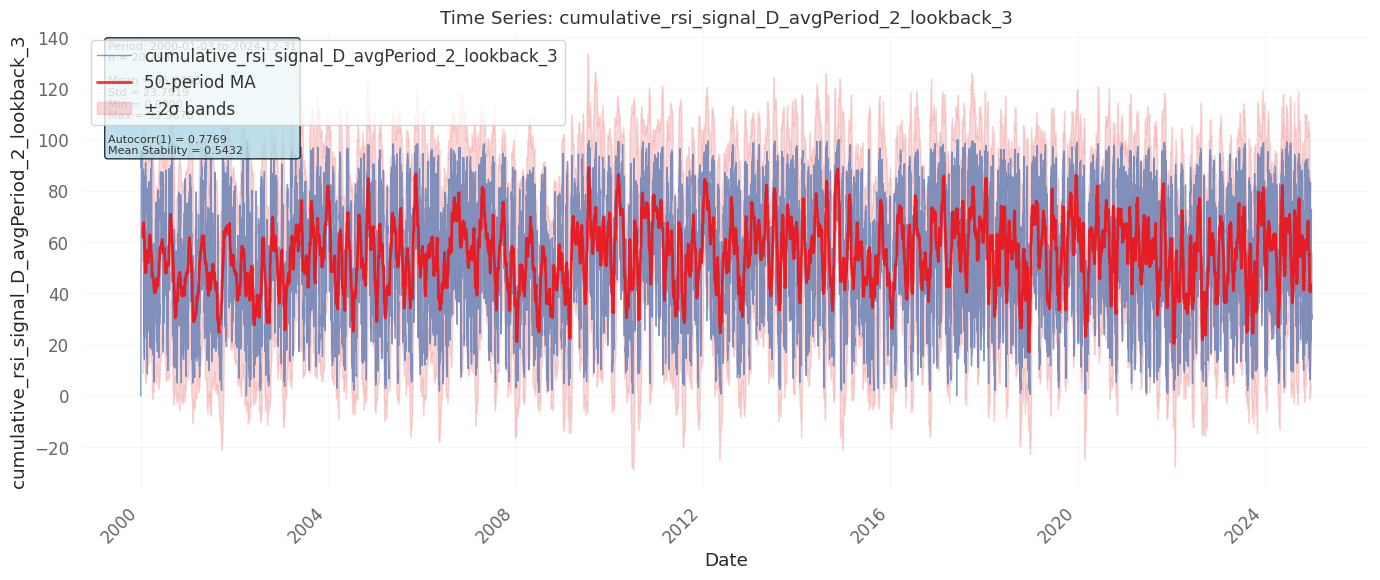

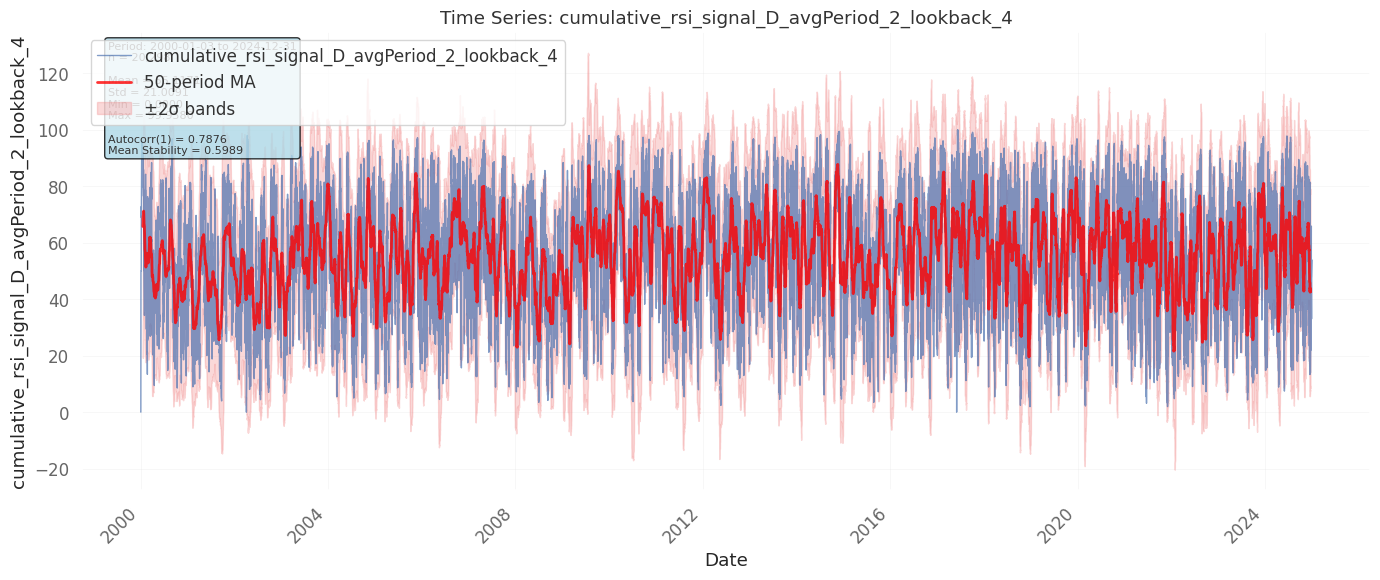

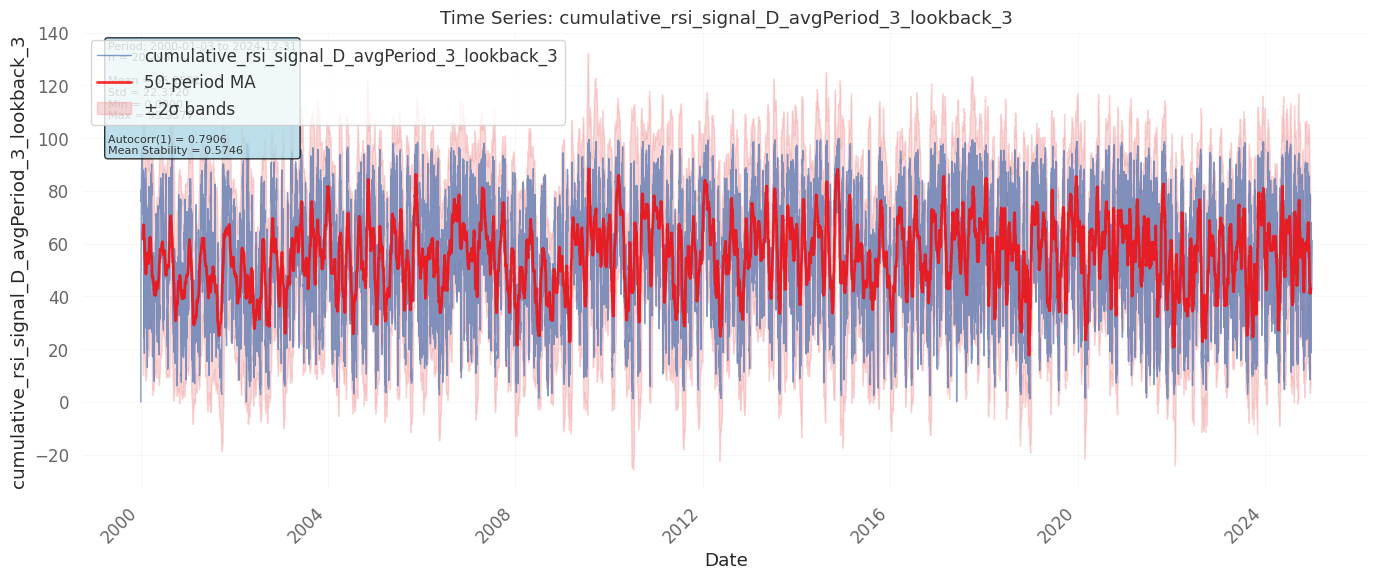

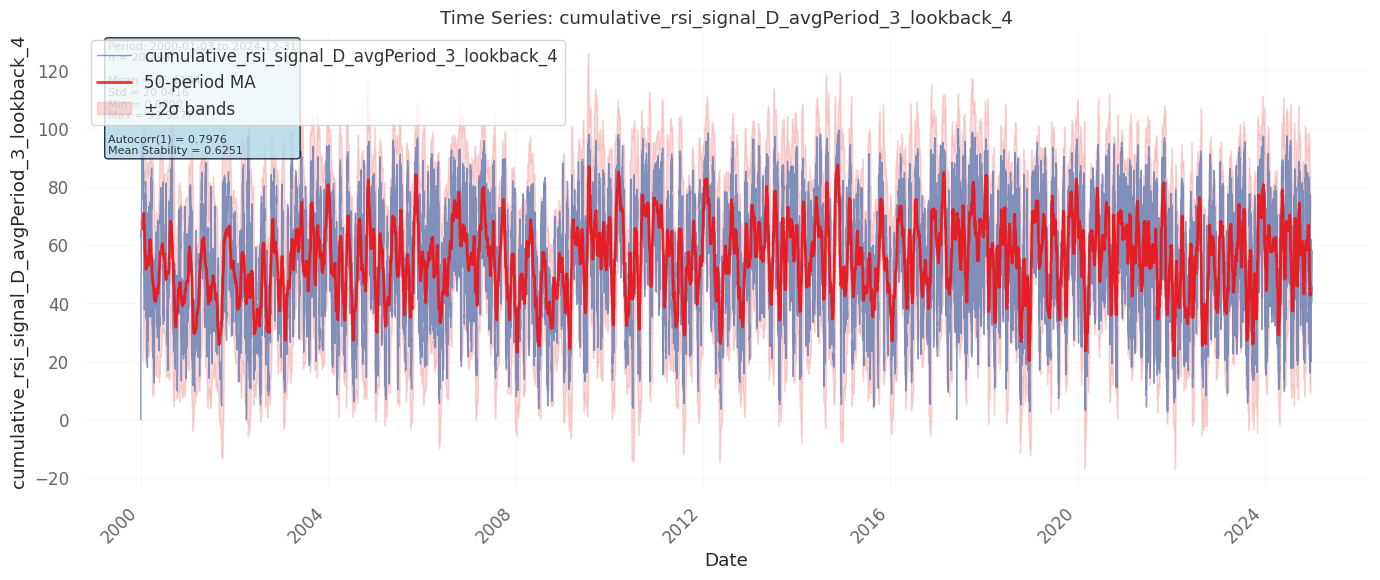

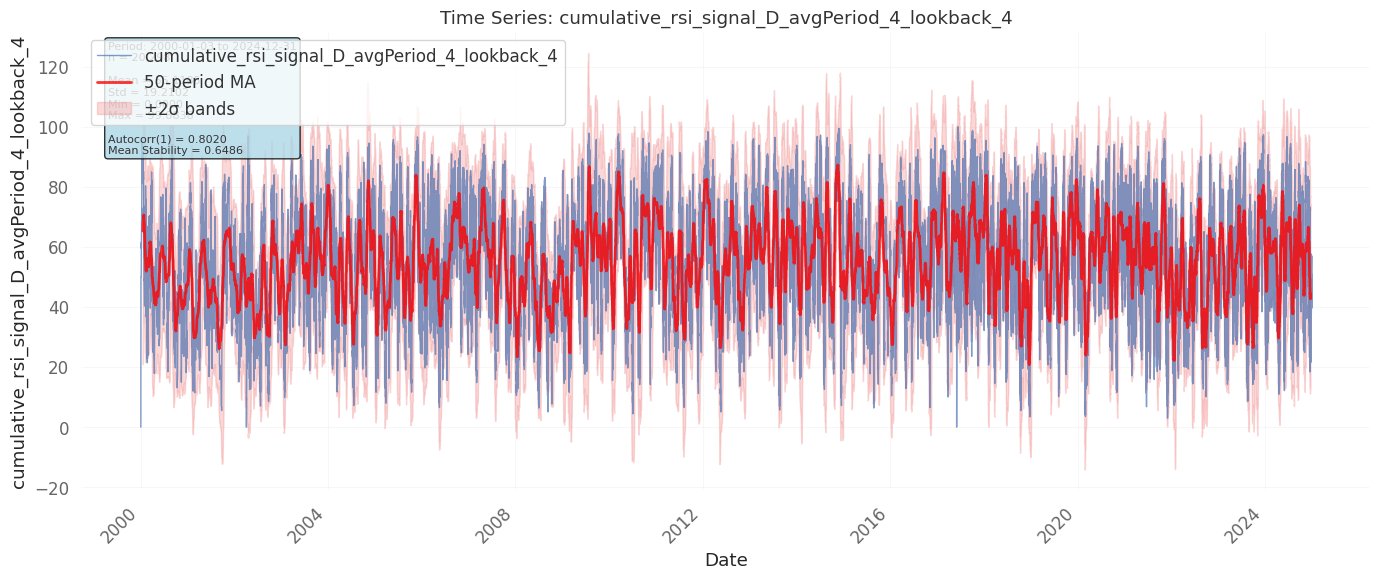

In [9]:
explorer.plot_distributions(bins=50)
plt.show()

explorer.plot_timeseries(rolling_window=50)
plt.show()

In [10]:

results = explorer.run_permutation_test(
    target_col='log_return',
    base_model=model,
    metric=metric,
    nreps=200
)


PERMUTATION TEST ENGINE
Strategy: FeaturePermutationStrategy
Features: 6
Replications: 200
Parallel workers: 12

Computing original criteria...
Successfully evaluated 6 features

Running 199 permutations...
  Using 12 parallel workers...
Completed 199 permutations

Results:
  Significant features (p <= 0.1): 0/6



Plotting signal-gated cumulative returns for 6 features
Target: log_return | Strategy: long-short

[1/6] cumulative_rsi_signal_D_avgPeriod_2_lookback_2
  ✓ Complete

[2/6] cumulative_rsi_signal_D_avgPeriod_2_lookback_3
  ✓ Complete

[3/6] cumulative_rsi_signal_D_avgPeriod_2_lookback_4
  ✓ Complete

[4/6] cumulative_rsi_signal_D_avgPeriod_3_lookback_3
  ✓ Complete

[5/6] cumulative_rsi_signal_D_avgPeriod_3_lookback_4
  ✓ Complete

[6/6] cumulative_rsi_signal_D_avgPeriod_4_lookback_4
  ✓ Complete


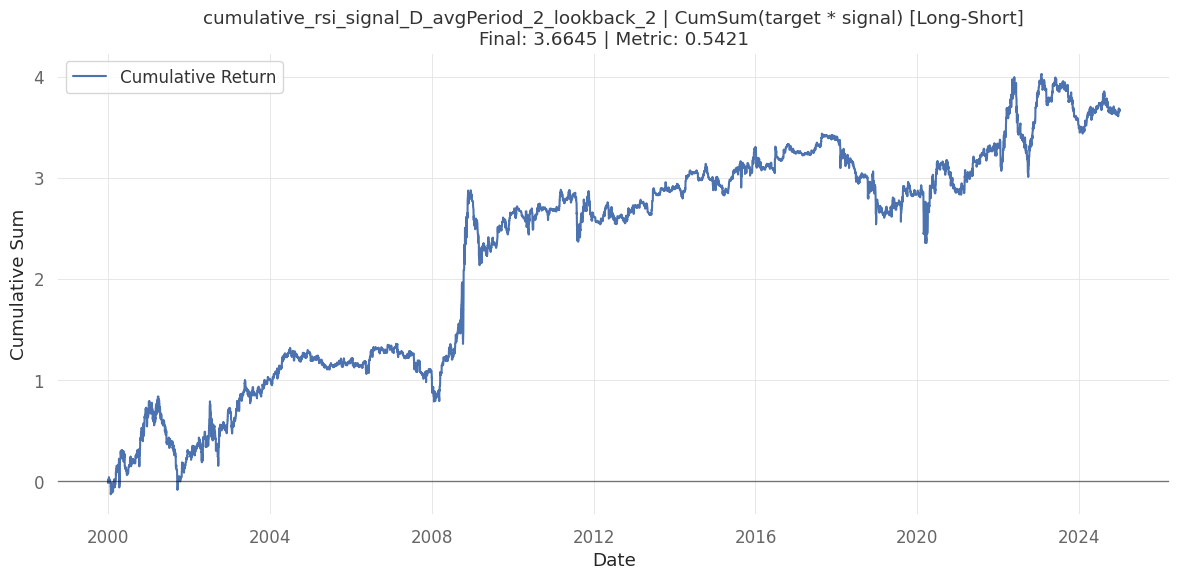

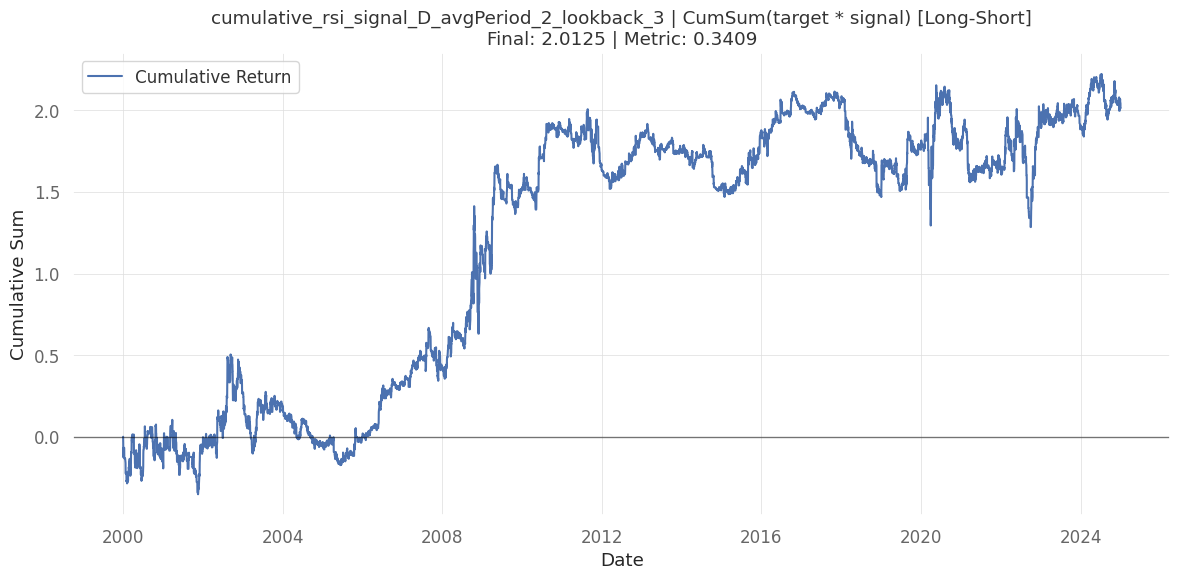

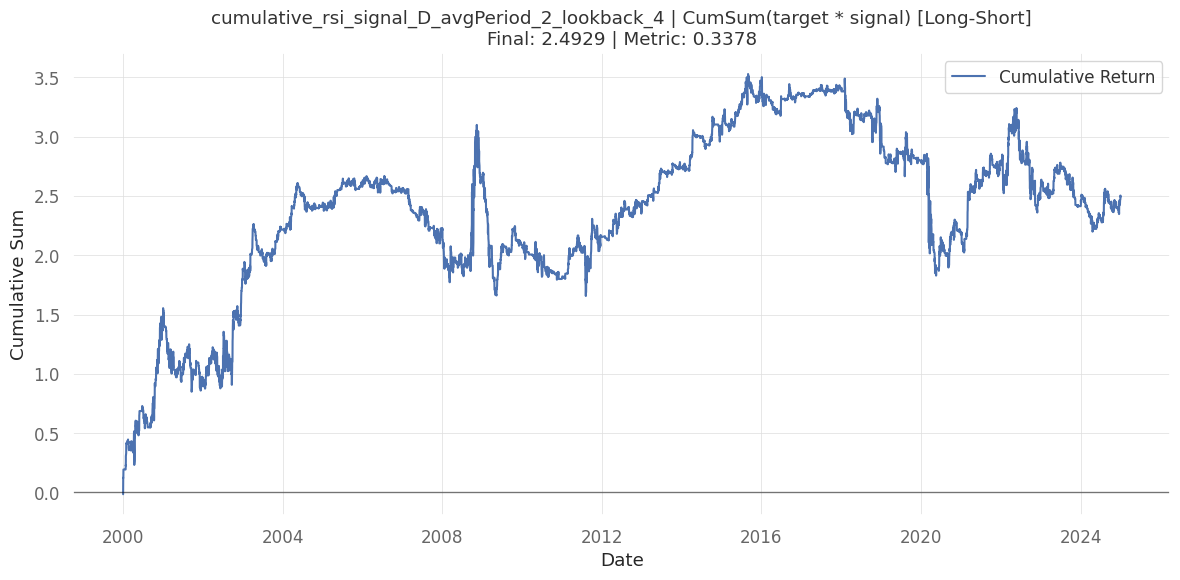

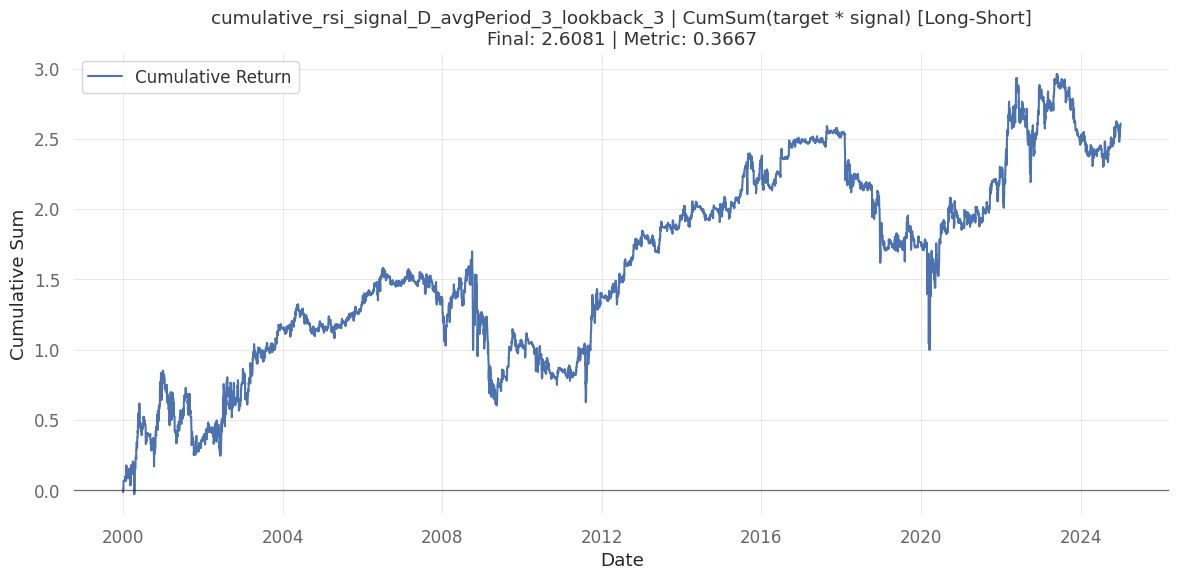

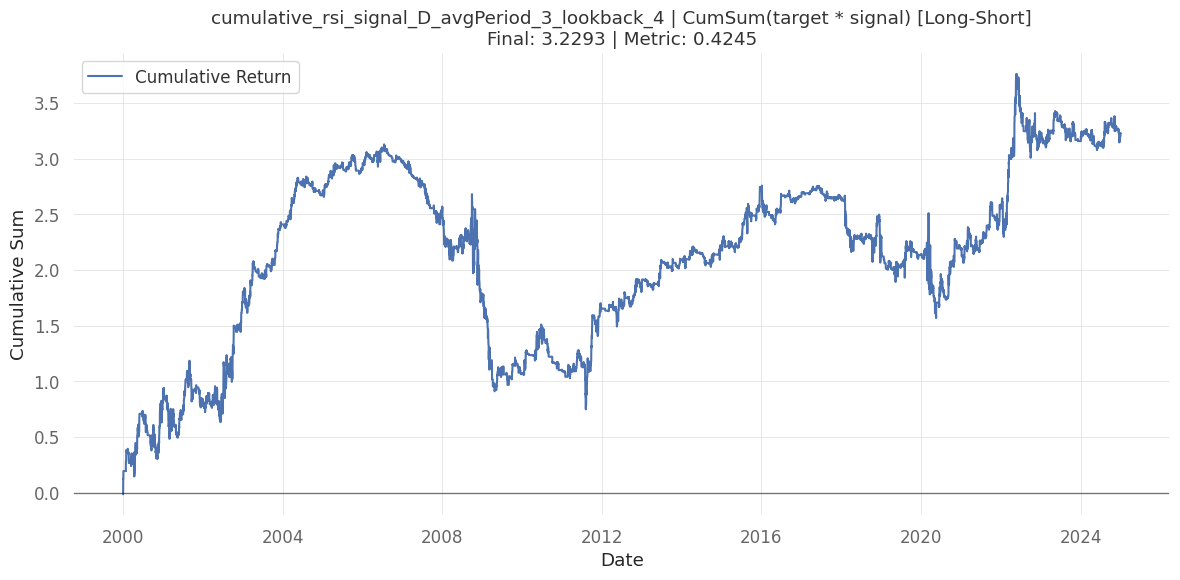

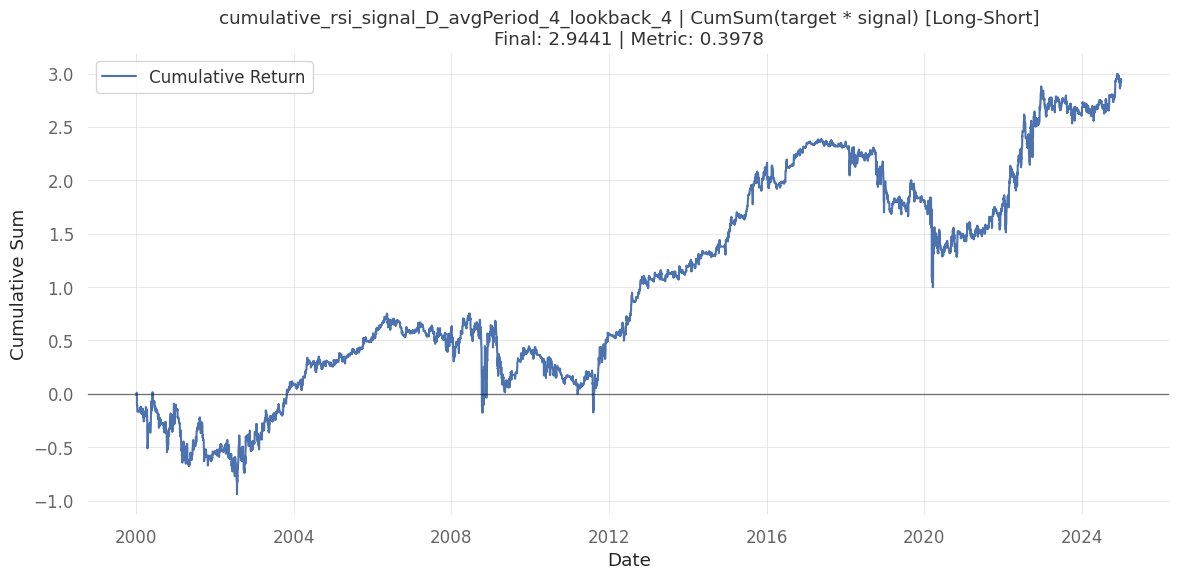

In [11]:
figs, summary = explorer.plot_signal_cumsum(
    target_col='log_return',
    base_model=model,
    show_plot=True,
    metric=metric,
    strategy='long-short'

)

In [12]:
df, fig = explorer.plot_parameter_sensitivity(
    module_name='cumulative_rsi',
    param_name='lookback',
    feature_name='signal',
    target_col='log_return', 
    base_model=model,
    custom_metric=metric
)


[DEBUG] analyze_parameter: 'cumulative_rsi_signal_D_avgPeriod_2_lookback_2' samples=20298 (feature NaNs=0, target NaNs=0)
[DEBUG] analyze_parameter: 'cumulative_rsi_signal_D_avgPeriod_2_lookback_3' samples=20298 (feature NaNs=0, target NaNs=0)
[DEBUG] analyze_parameter: 'cumulative_rsi_signal_D_avgPeriod_3_lookback_3' samples=20298 (feature NaNs=0, target NaNs=0)
[DEBUG] analyze_parameter: 'cumulative_rsi_signal_D_avgPeriod_2_lookback_4' samples=20298 (feature NaNs=0, target NaNs=0)
[DEBUG] analyze_parameter: 'cumulative_rsi_signal_D_avgPeriod_3_lookback_4' samples=20298 (feature NaNs=0, target NaNs=0)
[DEBUG] analyze_parameter: 'cumulative_rsi_signal_D_avgPeriod_4_lookback_4' samples=20298 (feature NaNs=0, target NaNs=0)


In [13]:
# New 2D parameter sensitivity with 3D surface plot
df_2d, fig_2d = explorer.plot_2d_parameter_surface(
    module_name='ewmac',
    param1_name='spanFast',
    param2_name='spanSlow',
    feature_name='signal',
    target_col='log_return', 
    base_model=model,
    custom_metric=metric
)

Building parameter grid for module 'ewmac'


ValueError: No features found for module='ewmac' with parameters 'spanFast' and 'spanSlow'.
Available modules: ['ewsd', 'cumulative_rsi', 'atr']
No parameters found for module 'ewmac'